In [1]:
import pandas as pd
from google.colab import drive
pd.set_option('display.max_columns', None)

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df= pd.read_csv('/content/drive/My Drive/Medical_Insurance_Prediction_Project/medical_insurance_cleaned_engineered.csv')

In [4]:
df

,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,annual_medical_cost,annual_premium,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,had_major_procedure,bp_category,bmi_group,ldl_group,hba1c_group,annual_medical_cost_grouped
0,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,1,27.4,Never,Never,2,0,0,4,121.0,76.0,123.8,5.28,Preferred Provider Organization,Bronze,1000,20,4,6938.06,876.05,0,0,0,0,0,0,0,0,1,0,0,Elevated,Overweight,Near Optimal,Normal,Low
1,79,Female,North,Urban,12800.0,High School Dropout,Married,Employed,3,1,26.6,Never,Weekly,2,0,0,3,131.0,79.0,97.3,4.82,Point-of-Service,Gold,1000,10,1,1632.61,445.10,0,0,0,0,0,0,0,0,1,1,0,Hypertension Stage 1,Overweight,Optimal,Normal,Very Low
2,68,Male,North,Rural,40700.0,High School,Married,Retired,5,3,31.5,Never,Never,1,0,0,4,160.0,84.0,129.5,5.51,Health Maintenance Organization,Platinum,500,20,10,7661.01,1538.02,1,0,0,0,0,1,0,0,0,1,0,Hypertension Stage 1,Obese I,Near Optimal,Normal,Low
3,15,Male,North,Suburban,15600.0,College,Married,Self-employed,5,3,31.6,Never,Never,0,0,0,1,104.0,68.0,160.3,8.50,Health Maintenance Organization,Silver,500,20,5,5130.27,820.63,0,1,0,0,0,0,0,0,0,0,0,Normal,Obese I,High,Diabetes,Low
4,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,0,30.5,Never,Daily,3,0,0,2,136.0,83.0,171.0,5.20,Point-of-Service,Platinum,500,10,7,1700.73,500.93,1,0,0,0,0,0,0,0,1,0,0,Hypertension Stage 1,Obese I,High,Normal,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,50,Male,West,Urban,127200.0,High School Dropout,Married,Employed,2,0,28.2,Never,Occasional,0,0,0,1,115.0,74.0,102.5,4.98,Preferred Provider Organization,Bronze,500,10,10,1295.04,329.32,0,0,0,0,0,0,0,0,0,0,0,Normal,Overweight,Near Optimal,Normal,Very Low
99996,42,Male,East,Suburban,21600.0,High School,Married,Employed,2,0,27.6,Never,Occasional,0,0,0,1,101.0,66.0,177.1,5.66,Preferred Provider Organization,Silver,5000,20,4,1451.73,424.21,0,0,0,0,0,0,0,0,0,0,0,Normal,Overweight,High,Normal,Very Low
99997,41,Male,West,Rural,81900.0,High School,Divorced,Unemployed,1,0,29.8,Former,Weekly,7,0,0,1,128.0,83.0,118.8,5.52,Preferred Provider Organization,Gold,500,30,9,2291.00,534.90,1,0,0,0,0,0,0,0,0,0,0,Hypertension Stage 1,Overweight,Near Optimal,Normal,Low
99998,51,Female,South,Urban,43400.0,Doctorate,Single,Unemployed,3,2,21.9,Never,Occasional,4,0,0,2,110.0,73.0,134.9,5.25,Point-of-Service,Bronze,2000,20,3,1279.76,342.86,0,0,0,0,0,0,0,0,0,1,0,Normal,Normal,Borderline High,Normal,Very Low


In [5]:
columns_to_drop = ['bp_category', 'bmi_group', 'ldl_group', 'hba1c_group', 'annual_medical_cost_grouped']
df = df.drop(columns=columns_to_drop)

In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Define target variable
target_variable = 'annual_premium'

# Separate features (X) and target (y)
X = df.drop(columns=[target_variable])
y = df[target_variable]

# Identify categorical and numerical features from X
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = X.select_dtypes(include=['number']).columns.tolist()

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(transformers=[('num', 'passthrough', numerical_features), ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])

# Create the XGBoost Regressor model pipeline with specified hyperparameters
model = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1))])

In [7]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'income',
                                                   'household_size',
                                                   'dependents', 'bmi',
                                                   'visits_last_year',
                                                   'hospitalizations_last_3yrs',
                                                   'days_hospitalized_last_3yrs',
                                                   'medication_count',
                                                   'systolic_bp',
                                                   'diastolic_bp', 'ldl',
                                                   'hba1c', 'deductible',
                                                   'copay', 'policy_term_years',
                                                   'annual_medical_cost',
                                                   'hypertens...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 6.21
Mean Squared Error (MSE): 5878.92
Root Mean Squared Error (RMSE): 76.67
R-squared (R2): 0.96


In [9]:
import joblib

# Define the filename for the saved model
xgboost_model_filename = '/content/drive/MyDrive/Medical_Insurance_Prediction_Project/xgboost_model.pkl'
joblib.dump(model, xgboost_model_filename)

['/content/drive/MyDrive/Medical_Insurance_Prediction_Project/xgboost_model.pkl']

In [10]:
import joblib

feature_names_filename = '/content/drive/MyDrive/Medical_Insurance_Prediction_Project/feature_names.pkl'
joblib.dump(X_train.columns.tolist(), feature_names_filename)

['/content/drive/MyDrive/Medical_Insurance_Prediction_Project/feature_names.pkl']

In [11]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])

In [12]:
# Split the data into training and testing sets (using the same split as before for consistency)
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest model
rf_model.fit(X_train_rf, y_train_rf)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'income',
                                                   'household_size',
                                                   'dependents', 'bmi',
                                                   'visits_last_year',
                                                   'hospitalizations_last_3yrs',
                                                   'days_hospitalized_last_3yrs',
                                                   'medication_count',
                                                   'systolic_bp',
                                                   'diastolic_bp', 'ldl',
                                                   'hba1c', 'deductible',
                                                   'copay', 'policy_term_years',
                                                   'annual_medical_cost',
                                                   'hypertens...
                                                   'cardiovascular_disease',
                                                   'cancer_history',
                                                   'kidney_disease',
                                                   'liver_disease', 'arthritis',
                                                   'mental_health',
                                                   'had_major_procedure']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'region',
                                                   'urban_rural', 'education',
                                                   'marital_status',
                                                   'employment_status',
                                                   'smoker', 'alcohol_freq',
                                                   'plan_type',
                                                   'network_tier'])])),
                ('regressor',
                 RandomForestRegressor(n_jobs=-1, random_state=42))])

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set using the Random Forest model
y_pred_rf = rf_model.predict(X_test_rf)

# Evaluate the Random Forest model
mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)
mse_rf = mean_squared_error(y_test_rf, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test_rf, y_pred_rf)

print(f"RandomForest Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")

RandomForest Model Evaluation:
Mean Absolute Error (MAE): 1.07
Mean Squared Error (MSE): 539.00
Root Mean Squared Error (RMSE): 23.22
R-squared (R2): 1.00


In [14]:
import joblib

rf_model_filename = '/content/drive/MyDrive/Medical_Insurance_Prediction_Project/random_forest_model.pkl'
joblib.dump(rf_model, rf_model_filename)

['/content/drive/MyDrive/Medical_Insurance_Prediction_Project/random_forest_model.pkl']

In [15]:
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Re-identifying categorical and numerical features from X
categorical_features_en = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features_en = X.select_dtypes(include=['number']).columns.tolist()

# Create a column transformer for ElasticNet, including StandardScaler for numerical features
preprocessor_en = ColumnTransformer(transformers=[('num', StandardScaler(), numerical_features_en), ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_en)])

# Create the ElasticNet model pipeline
elasticnet_model = Pipeline(steps=[('preprocessor', preprocessor_en), ('regressor', ElasticNet(random_state=42))])

In [16]:
# Split the data into training and testing sets (using the same split as before for consistency)
X_train_en, X_test_en, y_train_en, y_test_en = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the ElasticNet model
elasticnet_model.fit(X_train_en, y_train_en)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'income',
                                                   'household_size',
                                                   'dependents', 'bmi',
                                                   'visits_last_year',
                                                   'hospitalizations_last_3yrs',
                                                   'days_hospitalized_last_3yrs',
                                                   'medication_count',
                                                   'systolic_bp',
                                                   'diastolic_bp', 'ldl',
                                                   'hba1c', 'deductible',
                                                   'copay', 'policy_term_years',
                                                   'annual_medical_cost',
                                                   'hypert...
                                                   'cardiovascular_disease',
                                                   'cancer_history',
                                                   'kidney_disease',
                                                   'liver_disease', 'arthritis',
                                                   'mental_health',
                                                   'had_major_procedure']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'region',
                                                   'urban_rural', 'education',
                                                   'marital_status',
                                                   'employment_status',
                                                   'smoker', 'alcohol_freq',
                                                   'plan_type',
                                                   'network_tier'])])),
                ('regressor', ElasticNet(random_state=42))])

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set using the ElasticNet model
y_pred_en = elasticnet_model.predict(X_test_en)

# Evaluate the ElasticNet model
mae_en = mean_absolute_error(y_test_en, y_pred_en)
mse_en = mean_squared_error(y_test_en, y_pred_en)
rmse_en = np.sqrt(mse_en)
r2_en = r2_score(y_test_en, y_pred_en)

print(f"ElasticNet Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_en:.2f}")
print(f"Mean Squared Error (MSE): {mse_en:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_en:.2f}")
print(f"R-squared (R2): {r2_en:.2f}")

ElasticNet Model Evaluation:
Mean Absolute Error (MAE): 89.17
Mean Squared Error (MSE): 24642.03
Root Mean Squared Error (RMSE): 156.98
R-squared (R2): 0.85


In [18]:
import joblib

elasticnet_model_filename = '/content/drive/MyDrive/Medical_Insurance_Prediction_Project/elasticnet_model.pkl'
joblib.dump(elasticnet_model, elasticnet_model_filename)

['/content/drive/MyDrive/Medical_Insurance_Prediction_Project/elasticnet_model.pkl']

In [19]:
import lightgbm as lgb
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Re-identifying categorical and numerical features from X (using the same as ElasticNet for consistency)
categorical_features_lgb = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features_lgb = X.select_dtypes(include=['number']).columns.tolist()

# Create a column transformer for LightGBM, including StandardScaler for numerical features
preprocessor_lgb = ColumnTransformer(transformers=[('num', StandardScaler(), numerical_features_lgb), ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_lgb)])

# Create the LightGBM Regressor model pipeline
lightgbm_model = Pipeline(steps=[('preprocessor', preprocessor_lgb),('regressor', lgb.LGBMRegressor(random_state=42, n_jobs=-1))])

In [20]:
# Split the data into training and testing sets (using the same split as before for consistency)
X_train_lgb, X_test_lgb, y_train_lgb, y_test_lgb = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the LightGBM model
lightgbm_model.fit(X_train_lgb, y_train_lgb)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.093298 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1763
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 68
[LightGBM] [Info] Start training from score 581.869204


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'income',
                                                   'household_size',
                                                   'dependents', 'bmi',
                                                   'visits_last_year',
                                                   'hospitalizations_last_3yrs',
                                                   'days_hospitalized_last_3yrs',
                                                   'medication_count',
                                                   'systolic_bp',
                                                   'diastolic_bp', 'ldl',
                                                   'hba1c', 'deductible',
                                                   'copay', 'policy_term_years',
                                                   'annual_medical_cost',
                                                   'hypert...
                                                   'cardiovascular_disease',
                                                   'cancer_history',
                                                   'kidney_disease',
                                                   'liver_disease', 'arthritis',
                                                   'mental_health',
                                                   'had_major_procedure']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'region',
                                                   'urban_rural', 'education',
                                                   'marital_status',
                                                   'employment_status',
                                                   'smoker', 'alcohol_freq',
                                                   'plan_type',
                                                   'network_tier'])])),
                ('regressor', LGBMRegressor(n_jobs=-1, random_state=42))])

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set using the LightGBM model
y_pred_lgb = lightgbm_model.predict(X_test_lgb)

# Evaluate the LightGBM model
mae_lgb = mean_absolute_error(y_test_lgb, y_pred_lgb)
mse_lgb = mean_squared_error(y_test_lgb, y_pred_lgb)
rmse_lgb = np.sqrt(mse_lgb)
r2_lgb = r2_score(y_test_lgb, y_pred_lgb)

print(f"LightGBM Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_lgb:.2f}")
print(f"Mean Squared Error (MSE): {mse_lgb:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lgb:.2f}")
print(f"R-squared (R2): {r2_lgb:.2f}")

LightGBM Model Evaluation:
Mean Absolute Error (MAE): 7.13
Mean Squared Error (MSE): 6076.33
Root Mean Squared Error (RMSE): 77.95
R-squared (R2): 0.96


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [22]:
import joblib

lightgbm_model_filename = '/content/drive/MyDrive/Medical_Insurance_Prediction_Project/lightgbm_model.pkl'
joblib.dump(lightgbm_model, lightgbm_model_filename)

['/content/drive/MyDrive/Medical_Insurance_Prediction_Project/lightgbm_model.pkl']

In [23]:
import pandas as pd

# Create a dictionary to store the metrics for each model
metrics_data = {
    'Model': ['XGBoost', 'RandomForest', 'ElasticNet', 'LightGBM'],
    'MAE': [mae, mae_rf, mae_en, mae_lgb],
    'MSE': [mse, mse_rf, mse_en, mse_lgb],
    'RMSE': [rmse, rmse_rf, rmse_en, rmse_lgb],
    'R-squared': [r2, r2_rf, r2_en, r2_lgb]
}

# Create a DataFrame from the metrics data
metrics_df = pd.DataFrame(metrics_data)

# Display the DataFrame
print("Model Evaluation Metrics:")
display(metrics_df)

Model Evaluation Metrics:


,Model,MAE,MSE,RMSE,R-squared
0,XGBoost,6.205272,5878.920973,76.674122,0.963059
1,RandomForest,1.074690,538.999682,23.216367,0.996613
2,ElasticNet,89.168541,24642.033166,156.977811,0.845158
3,LightGBM,7.129837,6076.333129,77.950838,0.961818


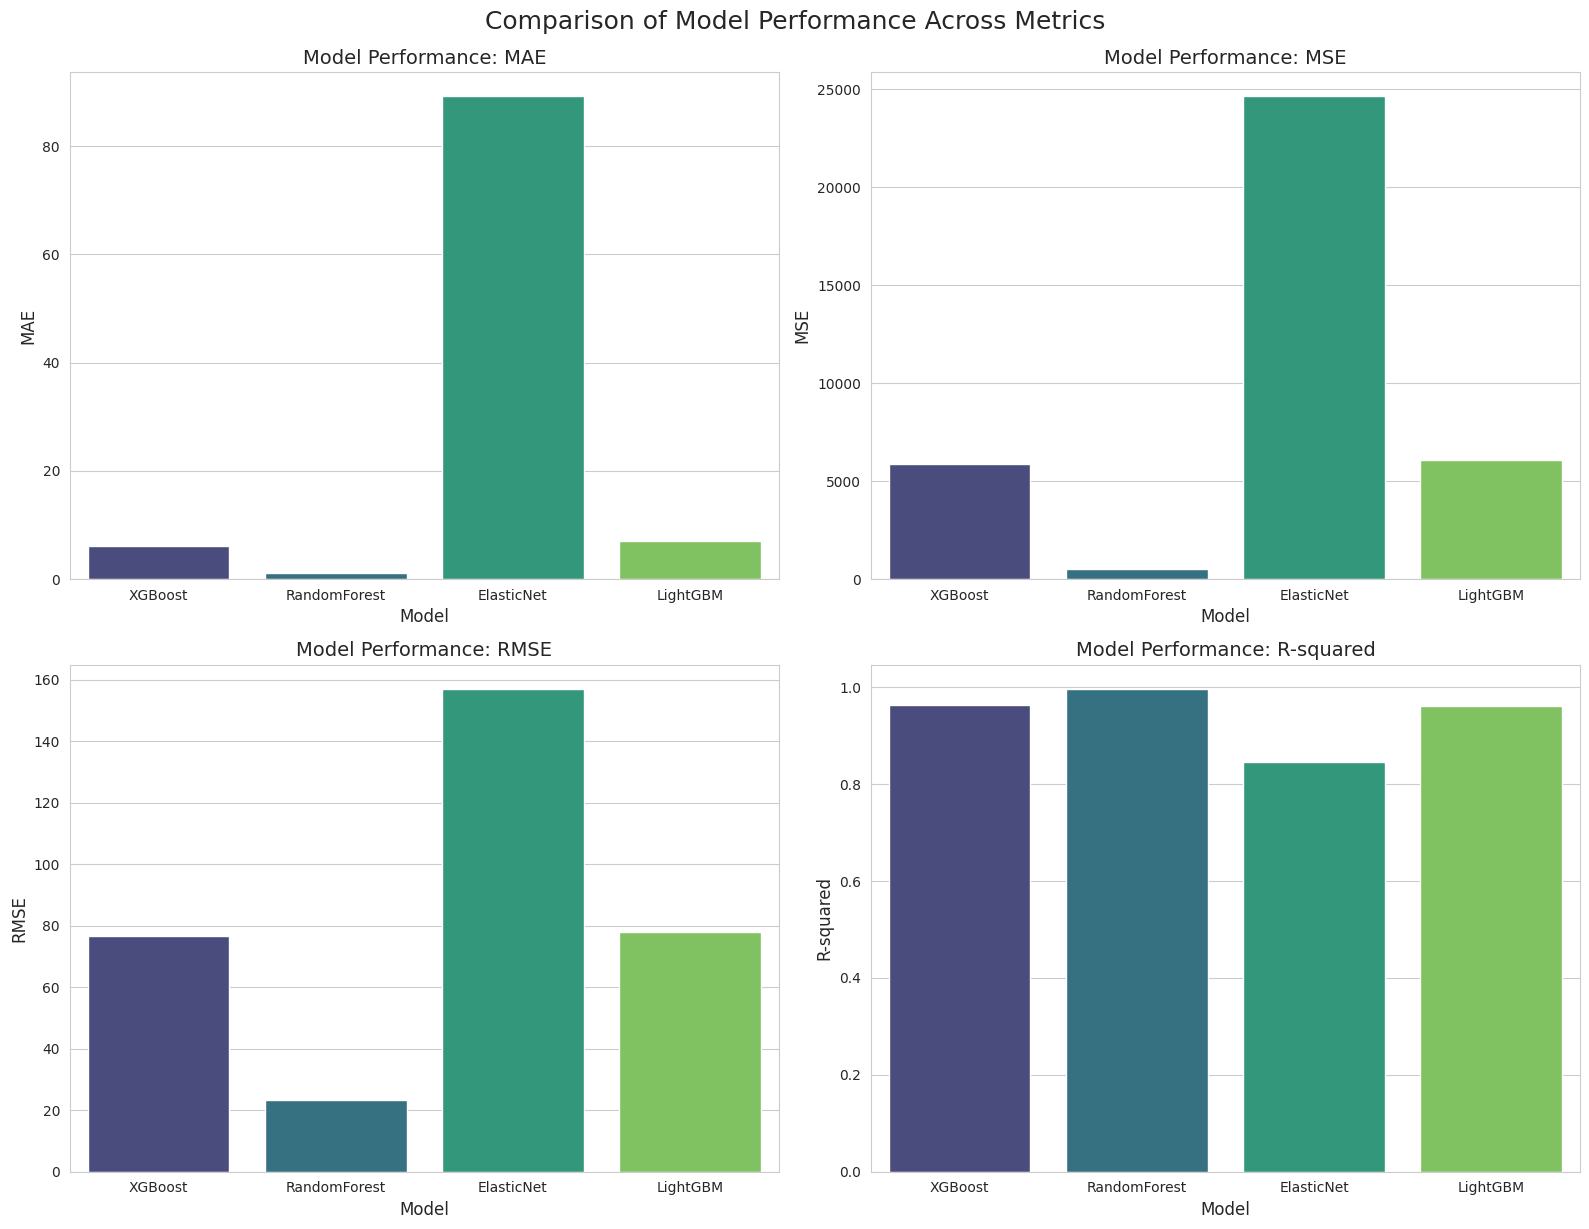

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Define the metrics to plot
metrics_to_plot = ['MAE', 'MSE', 'RMSE', 'R-squared']

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

# Iterate over each metric and create a bar plot
for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x='Model', y=metric, data=metrics_df, ax=axes[i], palette='viridis', hue='Model', legend=False)
    axes[i].set_title(f'Model Performance: {metric}', fontsize=14)
    axes[i].set_xlabel('Model', fontsize=12)
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].tick_params(axis='x', rotation=0)

# Adjust layout to prevent overlapping titles and labels
plt.tight_layout()
plt.suptitle('Comparison of Model Performance Across Metrics', y=1.02, fontsize=18)
plt.show()

In [25]:
import numpy as np

np.random.seed(42)
random_indices = np.random.choice(X_test.index, size=10, replace=False)

# Select the corresponding samples from X_test and y_test
X_sample = X_test.loc[random_indices]
y_actual_sample = y_test.loc[random_indices]

print("Selected 10 random samples for prediction comparison.")
print("Shape of X_sample:", X_sample.shape)
print("Shape of y_actual_sample:", y_actual_sample.shape)

Selected 10 random samples for prediction comparison.
Shape of X_sample: (10, 38)
Shape of y_actual_sample: (10,)


In [27]:
y_pred_xgboost_sample = model.predict(X_sample)
y_pred_randomforest_sample = rf_model.predict(X_sample)
y_pred_elasticnet_sample = elasticnet_model.predict(X_sample)
y_pred_lightgbm_sample = lightgbm_model.predict(X_sample)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [28]:
import pandas as pd

# Create a DataFrame to display the actual premiums and the predictions
prediction_comparison_df = pd.DataFrame({
    'Actual Premium': y_actual_sample,
    'XGBoost Predicted': y_pred_xgboost_sample,
    'RandomForest Predicted': y_pred_randomforest_sample,
    'ElasticNet Predicted': y_pred_elasticnet_sample,
    'LightGBM Predicted': y_pred_lightgbm_sample
})

print("DataFrame created for prediction comparison:")
display(prediction_comparison_df)


DataFrame created for prediction comparison:


,Actual Premium,XGBoost Predicted,RandomForest Predicted,ElasticNet Predicted,LightGBM Predicted
86525,401.92,404.556335,401.9017,580.322520,401.842859
4024,539.34,541.477600,539.3681,586.836639,539.498369
4731,273.43,273.226379,273.3945,317.037096,276.273567
46016,476.43,477.054016,476.6884,465.828117,479.676062
46674,316.04,316.114960,316.0380,393.207922,317.895016
76728,457.09,459.225708,456.9265,507.975411,455.789606
16434,585.57,589.329651,585.5335,601.034336,588.208502
63758,836.43,837.904785,837.4791,866.426314,847.063714
42976,292.79,292.080322,292.8331,355.175234,294.723893
96591,369.69,371.669495,369.6403,410.713955,366.270538


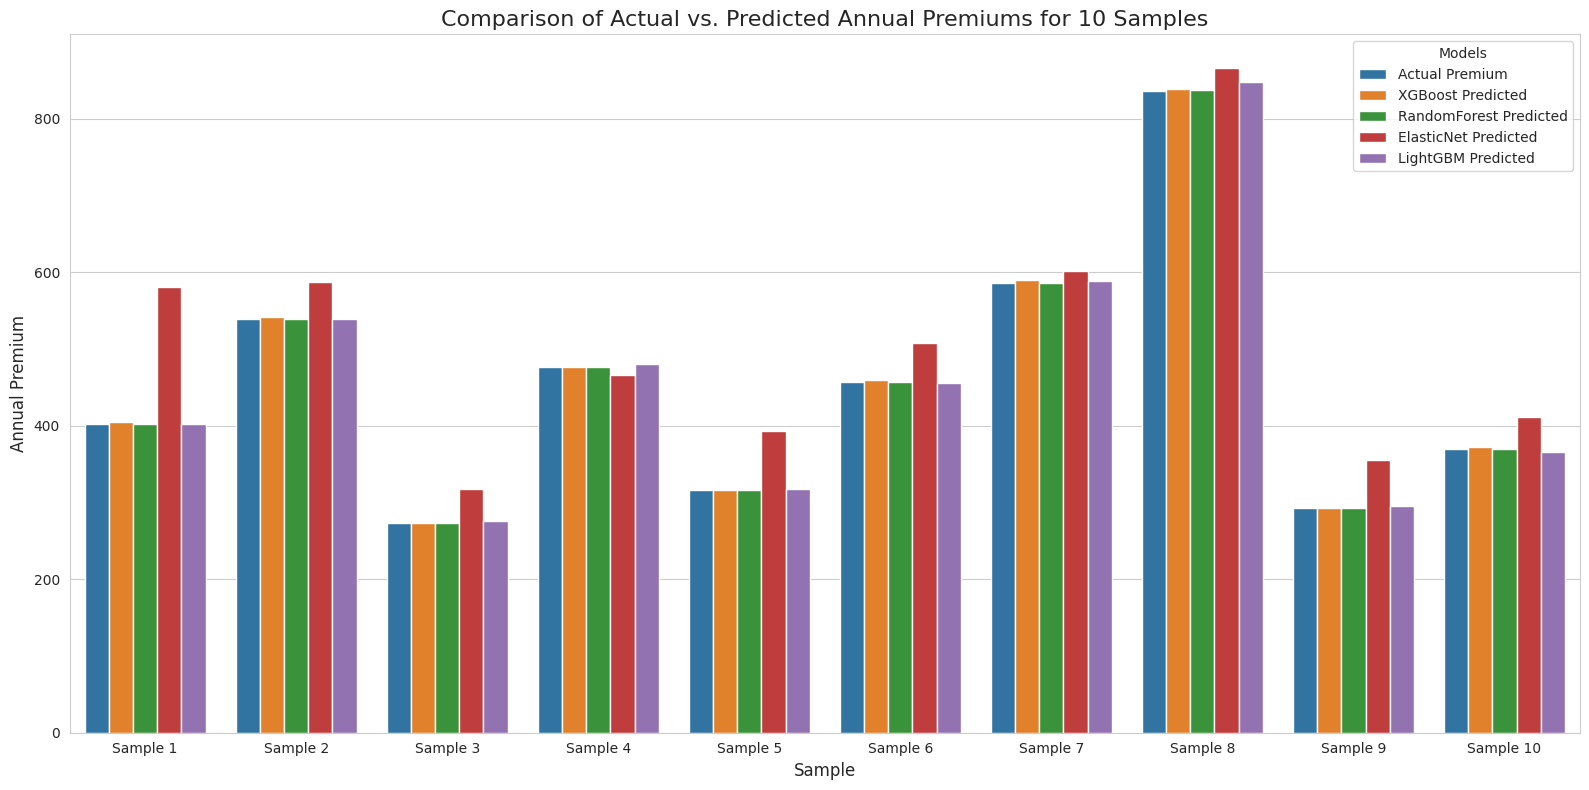

Clustered bar chart generated successfully with 'Sample' labels.


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to a long format for easier plotting with seaborn
prediction_comparison_melted = prediction_comparison_df.reset_index().melt(id_vars='index', var_name='Metric', value_name='Premium Value')

# Rename the 'index' column to 'Original Index' for clarity (as we'll create a new sample index)
prediction_comparison_melted = prediction_comparison_melted.rename(columns={'index': 'Original Index'})

# Create a new 'Sample' column for display, like 'Sample 1', 'Sample 2', etc. Get unique original indices and map them to new display names
unique_original_indices = prediction_comparison_melted['Original Index'].unique()
sample_label_map = {original_idx: f'Sample {i+1}' for i, original_idx in enumerate(unique_original_indices)}
prediction_comparison_melted['Sample Label'] = prediction_comparison_melted['Original Index'].map(sample_label_map)

# Set the aesthetic style of the plots
sns.set_style('whitegrid')

# Create a clustered bar chart
plt.figure(figsize=(16, 8))
sns.barplot(x='Sample Label', y='Premium Value', hue='Metric', data=prediction_comparison_melted, palette='tab10')

# Add titles and labels
plt.title('Comparison of Actual vs. Predicted Annual Premiums for 10 Samples', fontsize=16)
plt.xlabel('Sample', fontsize=12)
plt.ylabel('Annual Premium', fontsize=12)
plt.xticks(rotation=0, ha='center')
plt.legend(title='Models')
plt.tight_layout()
plt.show()

print("Clustered bar chart generated successfully with 'Sample' labels.")

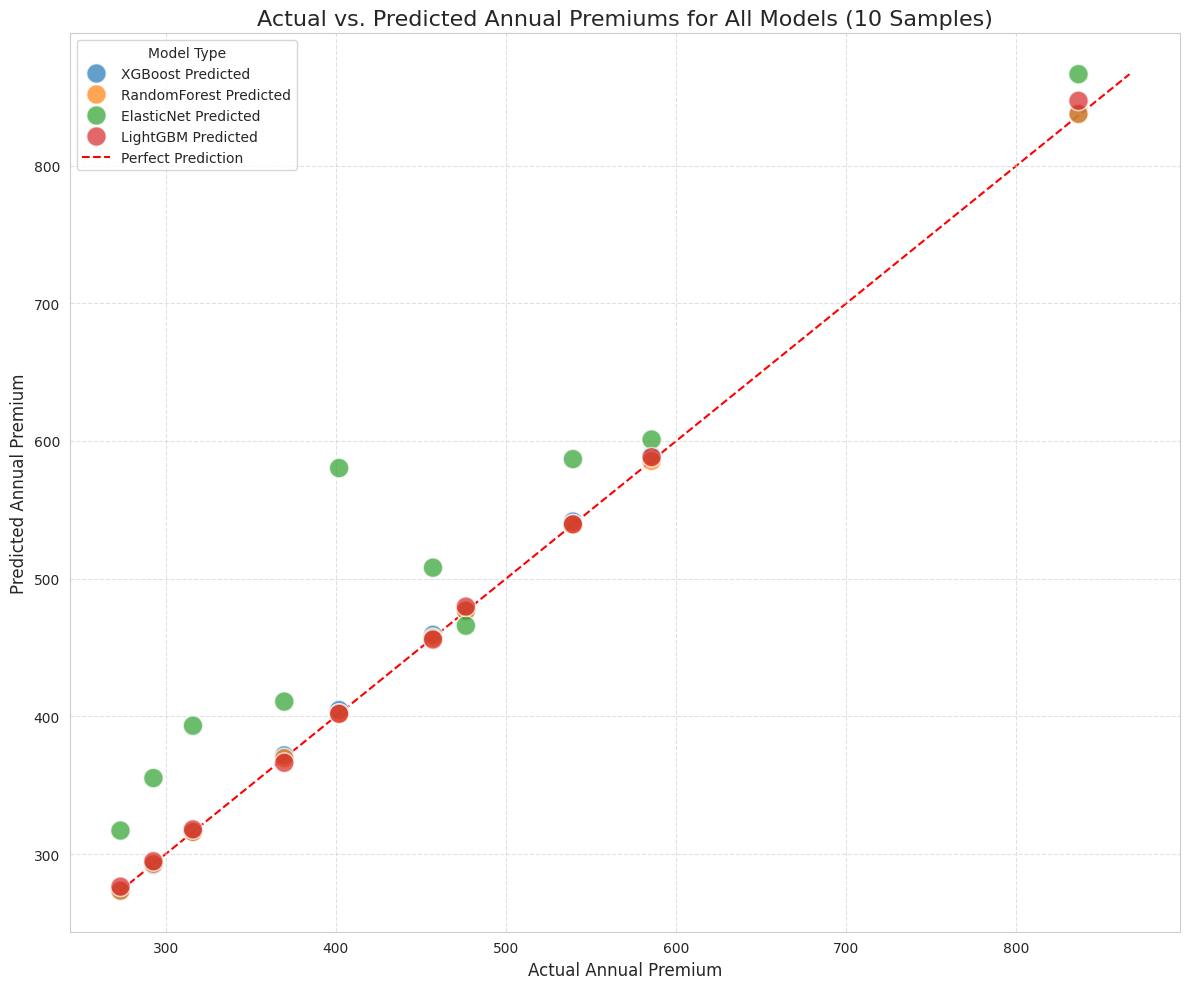

Scatter plot comparing actual vs. predicted values for all models generated successfully.


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Melt the prediction_comparison_df to long format for easier plotting
# Exclude 'Actual Premium' from melting as it will be the common x-axis
prediction_comparison_melted_all = prediction_comparison_df.melt(
    id_vars=['Actual Premium'],
    var_name='Model',
    value_name='Predicted Premium'
)

sns.set_style("whitegrid")
plt.figure(figsize=(12, 10))

# Create the scatter plot with different colors for each model
sns.scatterplot(
    x='Actual Premium',
    y='Predicted Premium',
    hue='Model',
    data=prediction_comparison_melted_all,
    palette='tab10',
    s=200, # size of the points
    alpha=0.7
)

# Plot the line of perfect prediction (y=x)
max_val = max(prediction_comparison_melted_all['Actual Premium'].max(), prediction_comparison_melted_all['Predicted Premium'].max())
min_val = min(prediction_comparison_melted_all['Actual Premium'].min(), prediction_comparison_melted_all['Predicted Premium'].min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction', zorder=0) # zorder to keep line behind points

plt.title('Actual vs. Predicted Annual Premiums for All Models (10 Samples)', fontsize=16)
plt.xlabel('Actual Annual Premium', fontsize=12)
plt.ylabel('Predicted Annual Premium', fontsize=12)
plt.legend(title='Model Type')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Scatter plot comparing actual vs. predicted values for all models generated successfully.")

In [34]:
import sklearn
print(sklearn.__version__)

1.6.1
